PLEASE NOTE: Some of the tools and data used in this tutorial are being updated as part of the ongoing 7th IPCC Assessment Cycle. Therefore, results may not reflect the latest scientific findings. An update of this tutorial will follow in due course. 



# From emissions to global mean temperature

Before an emissions scenario (such as GCAM output) can be used with RIME-X, the probabilistic temperature distribution of the scenario needs to be obtained. This can be done with the help of Simple Climate Models (SCMs) or climate emulator, such as MAGICC or FaIR. In order to run these SCMs for an emissions scenario, certain pre-processing steps are required though. These include:

* Harmonisation
* Infilling

To perform these pre-processing steps and run a climate emulator to obtain the probabilistic temperature output, we recommend to use the ```climate-assessment``` package, which was developed at IIASA and provides the option to assess emissions pathways in a way that is fully consistent with AR6. Comprehensive documentation for this package is available under

[https://climate-assessment.readthedocs.io/en/latest/index.html](https://climate-assessment.readthedocs.io/en/latest/index.html)

Although any of the provided climate emulators could be used, we recommend FaIR due to its easier installation process. 

The most important information is summarized in the paragraphs below.


### Installation of the climate-assessment package

Before starting the installation process, we recommend to create a new, clean Python environment to avoid versioning problems with already installed packages. 

The ```climate-assessment``` package can be installed using pip. For this, please use the following command:

* ```pip install climate-assessment```

Please make sure that netcdf is installed by using the following command:

* ```pip install netcdf4```.

### Downloading the infiller database

To reproduce the results from the Sixth Assessment Report Working Group III, the AR6 infiller database needs to be downloaded from the AR6 Scenario Explorer. For this, please follow the steps below:

* Go to the [AR6 Scenario Explorer](https://data.ene.iiasa.ac.at/ar6/)
* Click on 'Guest login' on the right
* Click on 'Downloads' at the top
* Scroll down to 'Data download'
* Download the 'Infiller database for silicone: IPCC AR6 WGIII version (DOI: 10.5281/zenodo.6390768)'

We recommend saving the database in the data folder where you cloned the climate-assessment package, e.g.  ```climate-assessment/data```.

### Set up FaIR

FaIR is already included in the ```climate-assessment``` package, but the required configuration files for FaIR need to be downloaded from [https://doi.org/10.5281/zenodo.5513021](https://doi.org/10.5281/zenodo.5513021). Please select the latest version v1.1 and download all three files. We recommend to save them in ```climate-assessment/data```.

### Import modules, set paths for required files for the climate assessment package and define functions

##### Import required modules

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import os
from climate_assessment.cli import run_workflow
import pyam
import requests
import matplotlib.pyplot as plt
import random as random
from matplotlib.ticker import MultipleLocator

##### Set paths and parameters

In [ ]:
#---- directory where all outputs should be stored
output_dir = '.'

#---- probabilistic file for FaIR
prob_file = 'path_to\\fair-1.6.2-wg3-params-slim.json'

#---- FaIR config file
fair_config = 'path_to\\fair-1.6.2-wg3-params-common.json'

#---- infilling database
infill_db = 'path_to\\1652361598937-ar6_emissions_vetted_infillerdatabase_10.5281-zenodo.6390768.csv'

##### Define required functions

In [5]:
#---- function for processing output from FaIR
def process_climate_output(model_name, scenario_name):

    #---- load FaIR output
    path = os.path.join(
        output_dir, 'raw_climate_output', 'FaIRv1.6.2', model_name, scenario_name,
        f'FaIRv1.6.2__{model_name}__{scenario_name}.nc'
    )
    ds = xr.open_dataset(path)

    #---- select temperature variable
    da = ds['Raw_Surface_Temperature_(GSAT)'].sel(unit='K')
    da['time'] = pd.DatetimeIndex(da.time.values).year
    df = da.sel(time=slice(1750, 2100)).squeeze().to_dataframe().reset_index()

    #---- bring data into the right format
    df = df.pivot(index='run_id', columns='time', values='Raw_Surface_Temperature_(GSAT)').reset_index()
    df['run_id'] = 'run_' + df['run_id'].rank(method='dense').astype(int).astype(str)
    df = df.set_index('run_id').T
    df.index.name = 'time'
    df.index = df.index.astype(int)

    #---- adjust temperature
    pre_industrial = df.loc[1850:1900].mean()
    df = df - pre_industrial
    df = df.loc[2015:2100]

    return df

### Load emissions data from a IIASA Scenario Explorer

##### Connect to Scenario Explorer instance and get a list of available models and scenarios


In [ ]:
#---- list all legacy databases
print('\n Legacy databases')
connection = pyam.iiasa.Connection()
connection.valid_connections

#---- list all available imxp4 platforms hosted by IIASA
# pyam.iiasa.platforms()

[INFO] 16:00:29 - ixmp4.conf.settingsmodel: Connecting as user 'werning'.



Platforms accessible via 'https://api.manager.ece.iiasa.ac.at/v1'

Name                Access    Notice
public-test         public    This is a public ixmp4 test instance.                     
ecemf               public    This is the public database instance for the Horizon 2... 
ssp-extensions      public    This is the SSP-Extensions project database. All data ... 
ecemf-internal      private   
ssp                 public    This platform has the scenarios and "basic drivers" (G... 
socdr               public    This platform contains the data for the "State of CDR ... 
socdr-internal      private   This platform is used to compile the key indicators an... 
shape               public    This database has key scenarios developed by the SHAPE... 
guide-internal      private   This is the project-internal platform for the GUIDE pr... 
idesignres-inter... private   This is the project-internal platform for the IDesignR... 
reconnect-intern... private   This is the project-internal plat

[INFO] 16:00:31 - pyam.iiasa: You are connected as user `werning`
[WARNING] 16:00:31 - pyam.iiasa: IIASA is migrating to a database infrastructure using the ixmp4 package.Use `pyam.iiasa.platforms()` to list available ixmp4 databases.


['deeds',
 'nexus_basins',
 'irp_internal',
 'ar6-public',
 'ngfs_phase_5_preview_short_term',
 'senses',
 'commit',
 'hotspots',
 'ar6',
 'ssp',
 'ecemf_internal',
 'jmip_internal',
 'gei',
 'committed_internal',
 'us_netzero2023_submission',
 'climate_solutions',
 'kopernikus',
 'ece_internal',
 'cmin',
 'openmod4africa_internal',
 'integration-test',
 'edits_internal',
 'engage',
 'paris_lttg',
 'cdlinks',
 'ixmp-dev',
 'emf37_internal',
 'ngfs_phase_2',
 'geidco',
 'ripples',
 'navigate_internal',
 'elevate_internal',
 'india_scenario_hub',
 'shape_internal',
 'geo7_internal',
 'set_nav',
 'ngfs_phase_4_preview',
 'ngfs_internal',
 'edits_india',
 'ariadne',
 'ngfs_phase_4_internal',
 'eu-climate-advisory-board-internal',
 'edits_india_internal',
 'aqnea',
 'india_projects_internal',
 'netzero2040',
 'engage_internal',
 'sandbox_dev',
 'sandbox',
 'ssp_internal',
 'aqnea_internal',
 'circomod',
 'netzero2040_internal',
 'eu-climate-advisory-board',
 'genie',
 'genie_internal',
 'ia

In [7]:
#---- select Scenario Explorer
scenario_explorer = 'ar6-public'

#---- connect to legacy Scenario Explorer and load list with all available models
conn = pyam.iiasa.Connection(scenario_explorer)
conn.models()

#---- connect to ixmp4 Scenario Explorer and load list with all available models
# conn = ixmp4.Platform(scenario_explorer)
# conn.models.tabulate()

[INFO] 16:00:39 - pyam.iiasa: You are connected to the IXSE_AR6_PUBLIC scenario explorer hosted by IIASA. If you use this data in any published format, please cite the data as provided in the explorer guidelines: https://data.ece.iiasa.ac.at/ar6/#/about
[INFO] 16:00:39 - pyam.iiasa: You are connected as user `werning`


0                                    GENeSYS-MOD 1.0
1                                        AIM/CGE 2.2
2                                         COFFEE 1.1
3                                           GCAM 5.3
4                                        GCAM-PR 5.3
                           ...                      
184    IEA Energy Technology Perspectives Model 2020
185                            AIM/Hub-Indonesia 2.0
186                                    REmap GRO2020
187                                 TIAM-ECN ETH 1.1
188                                    CEPRO-CHN 1.0
Name: model, Length: 189, dtype: object

In [8]:
#---- load list with all available scenarios (legacy)
conn.scenarios().head()

#---- load list with all availabe scenarios (ixmp4)
# conn.scenarios.tabulate()

0                    1
1    EN_INDCi2030_1000
2    EN_INDCi2030_500f
3    EN_INDCi2030_600f
4    EN_INDCi2030_700f
Name: scenario, dtype: object

##### Load emissions data from Scenario Explorer


In [9]:
#---- select model and scenario to be loaded - either string or list of strings, wildcards
#     can also be used (see https://pyam-iamc.readthedocs.io/en/v2.3.0/api/filtering.html)
scenarios = {'GCAM 5.3': ['NGFS2_Current Policies'], 'REMIND-MAgPIE 2.1-4.3': ['DeepElec_SSP2_ HighRE_Budg900']}

raw_data_list = []

for model in scenarios:

    for scen in scenarios[model]:

        #---- read data from legacy Scenario Explorer
        raw_data = pyam.read_iiasa(scenario_explorer, model=model, scenario=scen, variable='Emissions*', region="World")
        
        #---- read data from ixmp4 Scenario Explorer
        # raw_data = pyam.read_ixmp4(scenario_explorer, model=model, scenario=scen, variable='Emissions*', region="World")

        raw_data_list.append(raw_data)

raw_emissions = pyam.concat(raw_data_list)
raw_emissions = raw_emissions.timeseries().reset_index()
raw_emissions

[INFO] 16:00:59 - pyam.iiasa: You are connected to the IXSE_AR6_PUBLIC scenario explorer hosted by IIASA. If you use this data in any published format, please cite the data as provided in the explorer guidelines: https://data.ece.iiasa.ac.at/ar6/#/about
[INFO] 16:00:59 - pyam.iiasa: You are connected as user `werning`
[INFO] 16:01:03 - pyam.iiasa: You are connected to the IXSE_AR6_PUBLIC scenario explorer hosted by IIASA. If you use this data in any published format, please cite the data as provided in the explorer guidelines: https://data.ece.iiasa.ac.at/ar6/#/about
[INFO] 16:01:03 - pyam.iiasa: You are connected as user `werning`


,model,scenario,region,variable,unit,2005,2010,2015,2020,2025,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
0,GCAM 5.3,NGFS2_Current Policies,World,Emissions|BC,Mt BC/yr,NaN,7.841505,8.113908,7.211848,6.895572,...,4.994660,4.870544,4.956052,4.845856,4.806695,5.012086,4.910428,4.907353,5.244688,5.159410
1,GCAM 5.3,NGFS2_Current Policies,World,Emissions|BC|AFOLU,Mt BC/yr,NaN,2.574927,2.851034,2.292039,2.235374,...,1.917225,1.874965,1.847375,1.820309,1.809528,1.796257,1.788080,1.784426,1.781071,1.779123
2,GCAM 5.3,NGFS2_Current Policies,World,Emissions|BC|Energy,Mt BC/yr,NaN,5.266578,5.262874,4.919809,4.660199,...,3.077435,2.995579,3.108676,3.025547,2.997167,3.215829,3.122348,3.122928,3.463617,3.380287
3,GCAM 5.3,NGFS2_Current Policies,World,Emissions|BC|Energy|Demand|Industry,Mt BC/yr,NaN,0.753443,0.719068,0.699286,0.683997,...,0.693204,0.692041,0.677035,0.651630,0.617815,0.580302,0.544981,0.513217,0.483476,0.462163
4,GCAM 5.3,NGFS2_Current Policies,World,Emissions|BC|Energy|Demand|Residential and Com...,Mt BC/yr,NaN,2.508943,2.311416,2.044519,1.755239,...,0.533120,0.438678,0.361942,0.302897,0.254907,0.216534,0.186946,0.162550,0.141824,0.140375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,Emissions|VOC|Energy|Demand|Residential and Co...,Mt VOC/yr,30.0320,30.284200,29.434700,27.535800,23.697400,...,1.231600,0.342200,NaN,0.038400,NaN,0.037000,NaN,0.036100,NaN,0.030500
197,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,Emissions|VOC|Energy|Demand|Transportation,Mt VOC/yr,19.6874,24.770500,24.396800,25.260200,22.596300,...,2.324100,2.220000,NaN,2.204800,NaN,2.263100,NaN,2.362900,NaN,2.465700
198,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,Emissions|VOC|Energy|Supply,Mt VOC/yr,16.1272,16.540400,16.783800,17.040900,16.869300,...,10.968100,10.676300,NaN,10.196700,NaN,9.762900,NaN,9.325300,NaN,8.894500
199,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,Emissions|VOC|Other,Mt VOC/yr,27.8726,27.872600,29.406200,30.939800,32.473400,...,23.326700,22.839200,NaN,21.864400,NaN,20.889500,NaN,19.914700,NaN,18.939800


### Prepare data


In [10]:
#---- select required years (2015 - 2100) - change as required
start_year = 2015
end_year = 2100

#---- select columns for required years only
fixed_cols = raw_emissions.columns[:5]
year_columns = raw_emissions.columns[5:].astype(int)
mask = (year_columns >= start_year) & (year_columns <= end_year)
raw_emissions = raw_emissions.loc[:, list(fixed_cols) + list(raw_emissions.columns[5:][mask])]

#---- set index
raw_emissions = raw_emissions.set_index(['model','region','scenario','unit','variable'])
raw_emissions

2015  \
model                 region scenario                      unit      variable                                                        
GCAM 5.3              World  NGFS2_Current Policies        Mt BC/yr  Emissions|BC                                         8.113908   
                                                                     Emissions|BC|AFOLU                                   2.851034   
                                                                     Emissions|BC|Energy                                  5.262874   
                                                                     Emissions|BC|Energy|Demand|Industry                  0.719068   
                                                                     Emissions|BC|Energy|Demand|Residential and Comm...   2.311416   
...                                                                                                                            ...   
REMIND-MAgPIE 2.1-4.3 World  DeepElec_SSP2_ HighRE_Budg900 Mt VOC/yr Emissions|VOC|Energy|Demand|Residential and Com...  29.434700   
                                                                     Emissions|VOC|Energy|Demand|Transportation          24.396800   
                                                                     Emissions|VOC|Energy|Supply                         16.783800   
                                                                     Emissions|VOC|Other                                 29.406200   
                                                                     Emissions|VOC|Waste                                  2.160900   

                                                                                                                              2020  \
model                 region scenario                      unit      variable                                                        
GCAM 5.3              World  NGFS2_Current Policies        Mt BC/yr  Emissions|BC                                         7.211848   
                                                                     Emissions|BC|AFOLU                                   2.292039   
                                                                     Emissions|BC|Energy                                  4.919809   
                                                                     Emissions|BC|Energy|Demand|Industry                  0.699286   
                                                                     Emissions|BC|Energy|Demand|Residential and Comm...   2.044519   
...                                                                                                                            ...   
REMIND-MAgPIE 2.1-4.3 World  DeepElec_SSP2_ HighRE_Budg900 Mt VOC/yr Emissions|VOC|Energy|Demand|Residential and Com...  27.535800   
                                                                     Emissions|VOC|Energy|Demand|Transportation          25.260200   
                                                                     Emissions|VOC|Energy|Supply                         17.040900   
                                                                     Emissions|VOC|Other                                 30.939800   
                                                                     Emissions|VOC|Waste                                  2.047900   

                                                                                                                              2025  \
model                 region scenario                      unit      variable                                                        
GCAM 5.3              World  NGFS2_Current Policies        Mt BC/yr  Emissions|BC                                         6.895572   
                                                                     Emissions|BC|AFOLU                                   2.235374   
                                                                     Emissions|BC|Energy                

### Run climate assessment package with FaIR


In [11]:
#---- Please note: if you have already run this once and try to run it again with the same data,
#     it will fail and result in a NonUniqueMetadataError error. To avoid this, please remove 
#     all the files created in the previous climate assessment run. 

#---- loop over all scenarios and process them separately (if data include more than one scenario)
for scenario, df_scenario in raw_emissions.groupby('scenario'):
    
    #---- extract scenario and model name from the data
    #---- spaces are replaced with dashes in line with the climate assessment package
    scenario_name = scenario if isinstance(scenario, str) else scenario[0]
    scenario_name = scenario_name.replace(' ', '-')
    model_name = df_scenario.index[0][0]
    model_name = model_name.replace(' ', '-').replace('/', '-')

    #---- save data that is used as input for the climate assessment run
    fair_input = os.path.join(output_dir, f'{model_name}_{scenario_name}_fair_input.csv')
    df_scenario.to_csv(fair_input)

    # #---- run the climate assessment (harmonisation, infilling, FaIR)
    run_workflow(
        fair_input,
        output_dir,
        model="FaIR",
        model_version="1.6.2",
        probabilistic_file=prob_file,
        fair_extra_config=fair_config,
        num_cfgs=2237,
        infilling_database=infill_db,
        scenario_batch_size=20,
        save_raw_climate_output=True,   # needs to be True to create probabilistic output
        postprocess=False
    )    
   
    #---- run post-processing steps to convert FaIR output into format required by RIME-X
    final = process_climate_output(model_name, scenario_name)
    final_path = os.path.join(output_dir, f'{model_name}_{scenario_name}_fair_output.csv')
    final.to_csv(final_path)


[INFO] 16:01:15 - pyam.core: Reading file REMIND-MAgPIE-2.1-4.3_DeepElec_SSP2_-HighRE_Budg900_fair_input.csv
c:\Users\werning\python\venvs\cli_106_rimex\Lib\site-packages\pyam\core.py:931: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.meta[name] = meta[name].combine_first(self.meta[name])
[WARNING] 16:01:15 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:01:15 - pyam.utils: Formatted data is empty.
[WARNING] 16:01:15 - pyam.core: Filtered IamDataFrame is empty!
Harmonisation: 1it [00:03,  3.50s/it]
[WARNING] 16:01:21 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:01:21 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:01:21 - pyam.core: Filtered IamDataFrame is empty!
[WARNING] 16:01:21 - pyam.core: Filtered IamDataFrame is empty!
[WARN

Note that the lead variable ['Emissions|CO2|Energy and Industrial Processes'] goes negative.


Filling required variables:   0%|          | 0/29 [00:00<?, ?it/s]c:\Users\werning\python\venvs\cli_106_rimex\Lib\site-packages\pyam\core.py:931: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.meta[name] = meta[name].combine_first(self.meta[name])
Filling required variables: 100%|██████████| 29/29 [00:01<00:00, 24.68it/s]
c:\Users\werning\python\venvs\cli_106_rimex\Lib\site-packages\pyam\core.py:931: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.meta[name] = meta[name].combine_first(self.meta[name])
1 model-scenario pairs (running in batches of 

### Plot scenario data

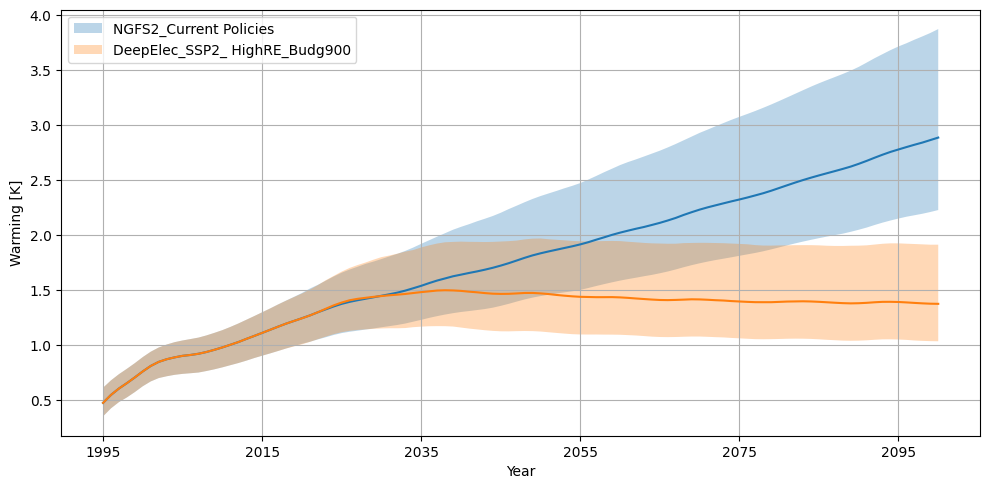

In [ ]:
scenarios = {'GCAM 5.3': ['NGFS2_Current Policies'], 'REMIND-MAgPIE 2.1-4.3': ['DeepElec_SSP2_ HighRE_Budg900']}
variables = ['AR6 climate diagnostics|Surface Temperature (GSAT)|FaIRv1.6.2|50.0th Percentile',
             'AR6 climate diagnostics|Surface Temperature (GSAT)|FaIRv1.6.2|5.0th Percentile',
             'AR6 climate diagnostics|Surface Temperature (GSAT)|FaIRv1.6.2|95.0th Percentile']

data_list = []

plt.figure(figsize=(10, 5))

for model in scenarios:

    model_name = model.replace(' ', '-').replace('/', '-')

    for scen in scenarios[model]:

        scenario_name = scen.replace(' ', '-')    

        data = pd.read_excel(os.path.join(output_dir, f'{model_name}_{scenario_name}_fair_input_rawoutput.xlsx'))
        data = data[data['Variable'].isin(variables)]

        p50 = data[data['Variable']=='AR6 climate diagnostics|Surface Temperature (GSAT)|FaIRv1.6.2|50.0th Percentile'].iloc[:,5:].melt()
        p5 = data[data['Variable']=='AR6 climate diagnostics|Surface Temperature (GSAT)|FaIRv1.6.2|5.0th Percentile'].iloc[:,5:].melt()
        p95 = data[data['Variable']=='AR6 climate diagnostics|Surface Temperature (GSAT)|FaIRv1.6.2|95.0th Percentile'].iloc[:,5:].melt()

        plt.plot(p50['variable'], p50['value'])
        plt.fill_between(p50['variable'], p5['value'], p95['value'], alpha=0.3, label=f'{scen}')

   
#---- set labels, titles and grid

plt.xlabel('Year')
plt.ylabel('Warming [K]')
plt.gca().xaxis.set_major_locator(MultipleLocator(tick_interval))
# plt.title(f'{meta["vars"][all_indicators.index(indicator)]["name"]} - {countries_and_regions[country]}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
